# Stock Market Analysis

This notebook follows the full analysis workflow: load the source CSVs, clean and validate each dataset, merge them into one analysis table, save that cleaned merged table to SQLite, explore the data, create charts, then export those charts and findings to a PDF.

Run all cells from top to bottom to recreate the analysis and PDF from the current CSV files.


## 1. Load the raw CSV files

Read every company file and retain the filename as a `company` label so the sources can be compared after merging.

In [ ]:
from pathlib import Path
import sys

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Could not locate the project data folder")
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.create_insights_report import (
    CHARTS, DATA_DIR, PDF_PATH, calculate_metrics, make_pdf,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 9, "axes.titlesize": 13, "axes.labelsize": 10, "legend.fontsize": 8})
CHARTS.mkdir(parents=True, exist_ok=True)
palette = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"]
company_colors = dict(zip(sorted(path.stem for path in DATA_DIR.glob("*.csv")), palette))


In [ ]:
csv_paths = sorted(DATA_DIR.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

raw_frames = []
for path in csv_paths:
    frame = pd.read_csv(path)
    frame["company"] = path.stem
    raw_frames.append(frame)

print(f"Loaded {len(raw_frames)} CSV files and {sum(len(frame) for frame in raw_frames):,} raw rows.")
display(pd.DataFrame({"file": [path.name for path in csv_paths], "rows": [len(frame) for frame in raw_frames]}))


## 2. Clean and validate

Standardize column names, parse dates and numeric fields, measure missing values and duplicate keys, and flag inconsistent OHLC prices. Rows without a valid date or close are excluded; unusual OHLC rows are reported for review rather than silently discarded.

In [ ]:
column_map = {
    "Date": "date", "Open Price": "open_price", "High Price": "high_price",
    "Low Price": "low_price", "Close Price": "close_price", "WAP": "wap",
    "No.of Shares": "shares_traded", "No. of Trades": "trades",
    "Total Turnover (Rs.)": "turnover", "Deliverable Quantity": "deliverable_quantity",
    "% Deli. Qty to Traded Qty": "deliverable_pct",
    "Spread High-Low": "spread_high_low", "Spread Close-Open": "spread_close_open",
}
numeric_columns = [name for name in column_map.values() if name != "date"]
clean_frames = []
validation_rows = []

for path, raw in zip(csv_paths, raw_frames):
    clean = raw.rename(columns=column_map).copy()
    clean["date"] = pd.to_datetime(clean["date"], format="mixed", dayfirst=True, errors="coerce")
    for column in numeric_columns:
        clean[column] = pd.to_numeric(
            clean[column].astype("string").str.replace(",", "", regex=False), errors="coerce"
        )
    duplicate_count = int(clean.duplicated(subset=["company", "date"]).sum())
    missing_date_count = int(clean["date"].isna().sum())
    missing_close_count = int(clean["close_price"].isna().sum())
    invalid_ohlc = (
        clean["high_price"].lt(clean["low_price"])
        | clean["close_price"].lt(clean["low_price"])
        | clean["close_price"].gt(clean["high_price"])
    )
    invalid_ohlc_count = int(invalid_ohlc.fillna(False).sum())
    validation_rows.append({
        "company": path.stem, "input_rows": len(clean), "duplicate_company_dates": duplicate_count,
        "invalid_dates": missing_date_count, "missing_closes": missing_close_count,
        "OHLC_consistency_flags": invalid_ohlc_count,
    })
    clean = clean.drop_duplicates(subset=["company", "date"])
    clean = clean.dropna(subset=["company", "date", "close_price"])
    clean_frames.append(clean)

validation = pd.DataFrame(validation_rows)
display(validation)
print(f"Removed {sum(row['duplicate_company_dates'] for row in validation_rows)} duplicate company-date rows and rows lacking a valid date or close.")


## 3. Merge company data

Concatenate the cleaned files into one long-form table with a consistent schema. This keeps the company label on every observation and makes grouped SQL and pandas analysis straightforward.

In [ ]:
df = pd.concat(clean_frames, ignore_index=True)
df = df.sort_values(["company", "date"]).reset_index(drop=True)
required = {"company", "date", "open_price", "high_price", "low_price", "close_price", "turnover", "deliverable_pct"}
missing_columns = required.difference(df.columns)
if missing_columns:
    raise ValueError(f"Merged data is missing required columns: {sorted(missing_columns)}")
if df.duplicated(subset=["company", "date"]).any():
    raise ValueError("Duplicate company-date keys remain after cleaning")

print(f"Merged table: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Companies: {df.company.nunique()} | Date range: {df.date.min():%Y-%m-%d} to {df.date.max():%Y-%m-%d}")
display(df.head())


## 3a. Save the cleaned merged data to SQLite

This cell replaces `database/stock_market.db`'s `stock_prices` table with the cleaned, validated merged data above. Run this cell to update the database; the CSV files remain unchanged.

In [ ]:
import sqlite3

DB_PATH = PROJECT_ROOT / "database" / "stock_market.db"
DB_PATH.parent.mkdir(parents=True, exist_ok=True)
database_df = df.copy()
database_df["date"] = database_df["date"].dt.strftime("%Y-%m-%d")
with sqlite3.connect(DB_PATH) as connection:
    database_df.to_sql("stock_prices", connection, if_exists="replace", index=False)
    connection.execute("CREATE INDEX idx_stock_company_date ON stock_prices(company, date)")
    saved_rows = connection.execute("SELECT COUNT(*) FROM stock_prices").fetchone()[0]

print(f"Saved {saved_rows:,} cleaned rows for {database_df.company.nunique()} companies to {DB_PATH}")


## 4. Exploratory data analysis

Review schema, null counts, price and activity distributions, and comparable company-level summaries before plotting.

In [ ]:
print("Data types and non-null counts:")
df.info()
print("Missing values by field:")
display(df.isna().sum().rename("missing").to_frame())
print("Numeric distributions:")
display(df[["close_price", "shares_traded", "turnover", "deliverable_pct"]].describe().T)

df["daily_return_pct"] = df.groupby("company")["close_price"].pct_change() * 100
eda_summary = df.groupby("company", as_index=False).agg(
    trading_days=("date", "nunique"), first_date=("date", "min"), last_date=("date", "max"),
    average_close=("close_price", "mean"), average_turnover=("turnover", "mean"),
    average_delivery_pct=("deliverable_pct", "mean"), daily_return_volatility_pct=("daily_return_pct", "std"),
)
display(eda_summary.round(2))
metrics = calculate_metrics(df)


## 5. Indexed closing prices

This cell indexes each company's close to 100 on its first available date, making differently priced shares easier to compare.

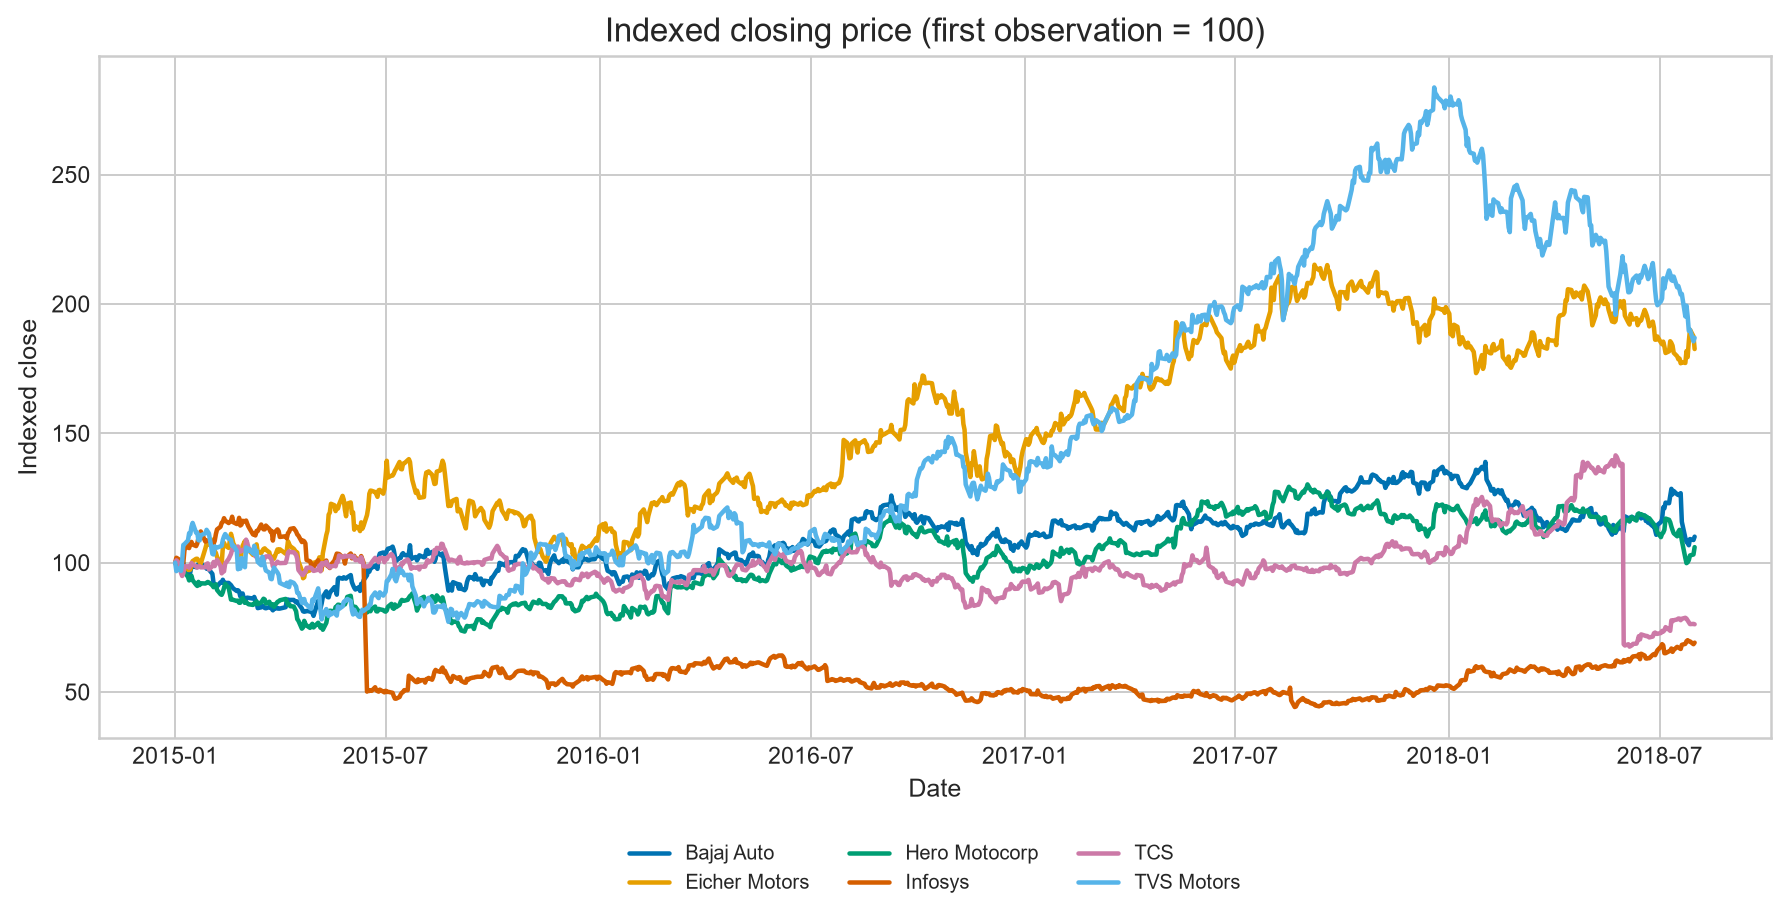

In [1]:
fig, ax = plt.subplots(figsize=(10, 5.2))
for company, group in df.dropna(subset=["close_price"]).groupby("company"):
    group = group.sort_values("date")
    first_close = group.close_price.iloc[0]
    if first_close:
        ax.plot(group.date, group.close_price / first_close * 100, label=company,
                color=company_colors.get(company), linewidth=1.8)
ax.set(title="Indexed closing price (first observation = 100)", ylabel="Indexed close", xlabel="Date")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(CHARTS / "indexed_closing_prices.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 6. Period price returns

This bar chart compares the percentage change between each company's first and last available closing price.

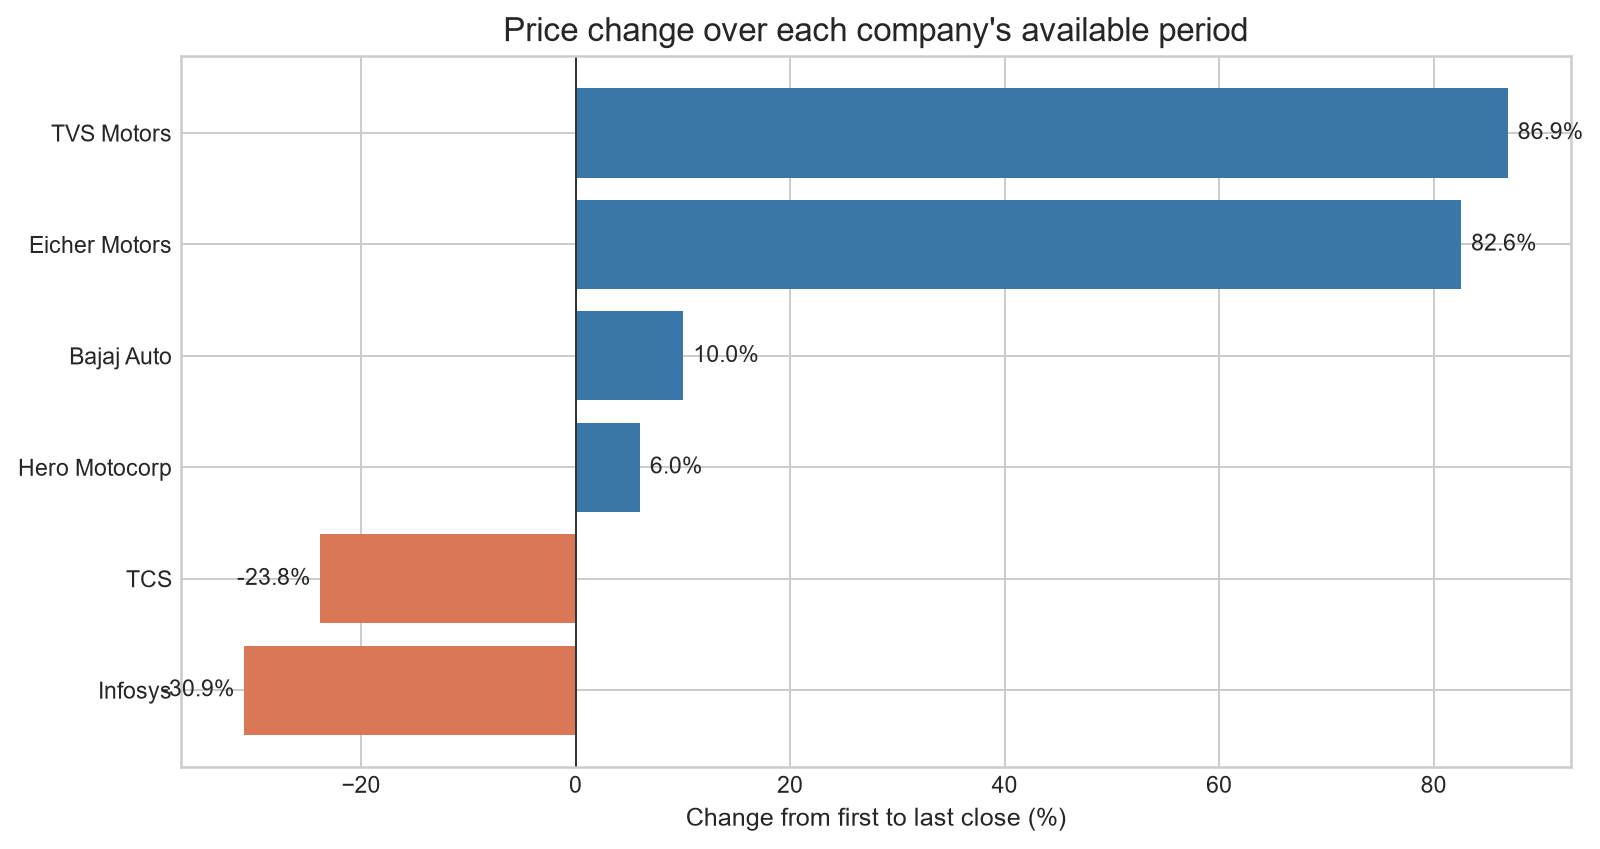

In [1]:
chart = metrics.sort_values("Return (%)")
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(chart.Company, chart["Return (%)"], color=["#d97757" if value < 0 else "#3977a8" for value in chart["Return (%)"]])
ax.axvline(0, color="#333333", linewidth=0.8)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set(title="Price change over each company's available period", xlabel="Change from first to last close (%)")
fig.tight_layout()
fig.savefig(CHARTS / "period_returns.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 7. Average daily turnover

This chart shows average daily turnover in rupee millions for each company.

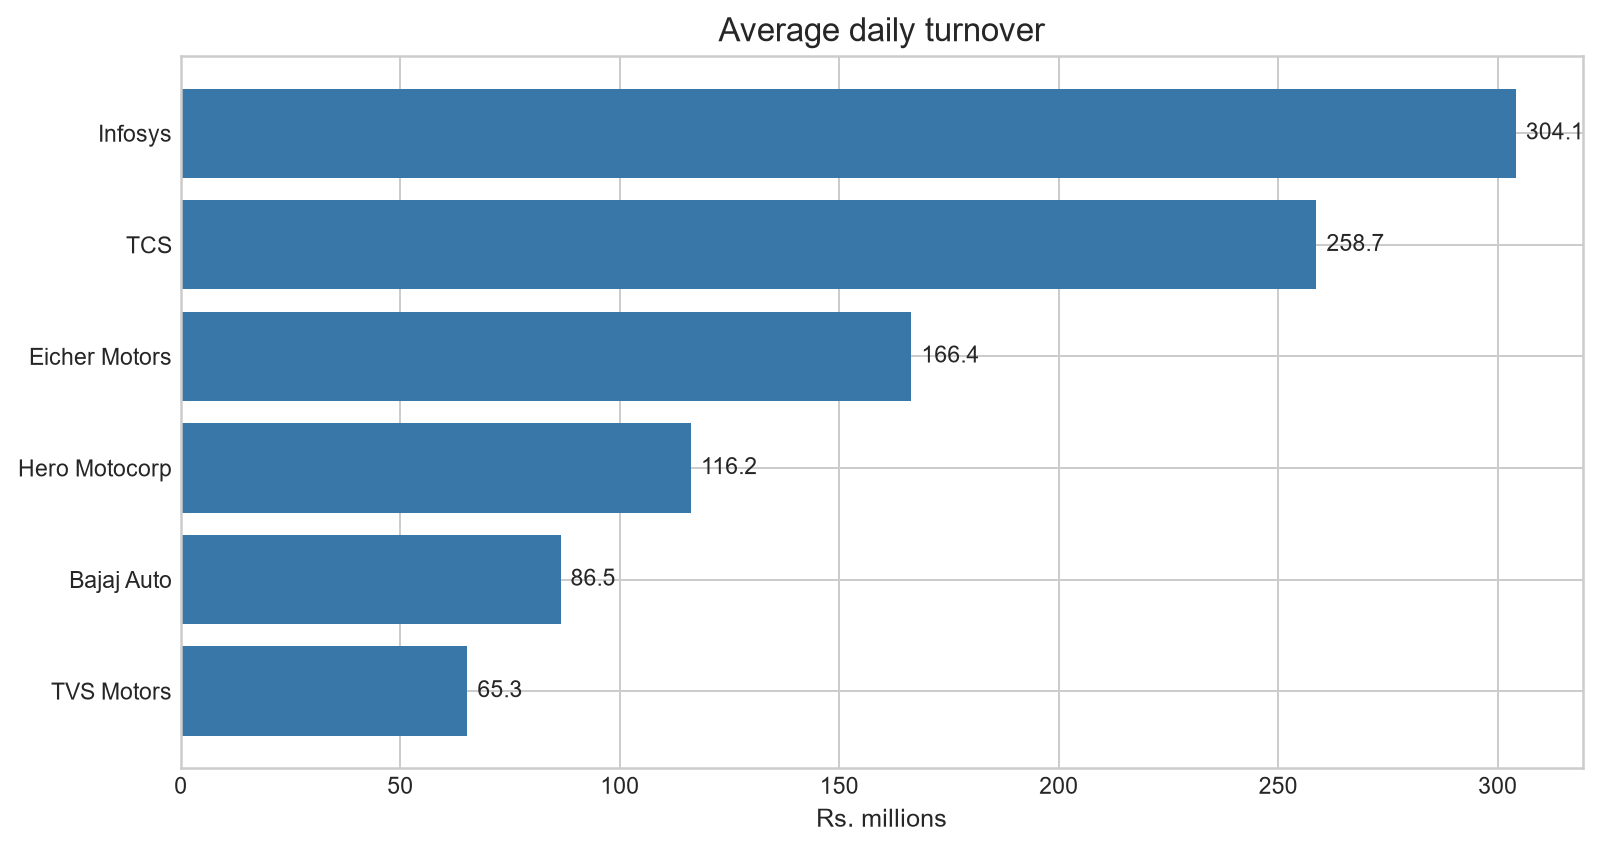

In [1]:
chart = metrics.sort_values("Avg turnover (Rs.)")
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(chart.Company, chart["Avg turnover (Rs.)"] / 1_000_000, color="#3977a8")
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=9)
ax.set(title="Average daily turnover", xlabel="Rs. millions")
fig.tight_layout()
fig.savefig(CHARTS / "average_turnover.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 8. Average delivery ratio

This chart compares the average deliverable quantity as a percentage of traded quantity.

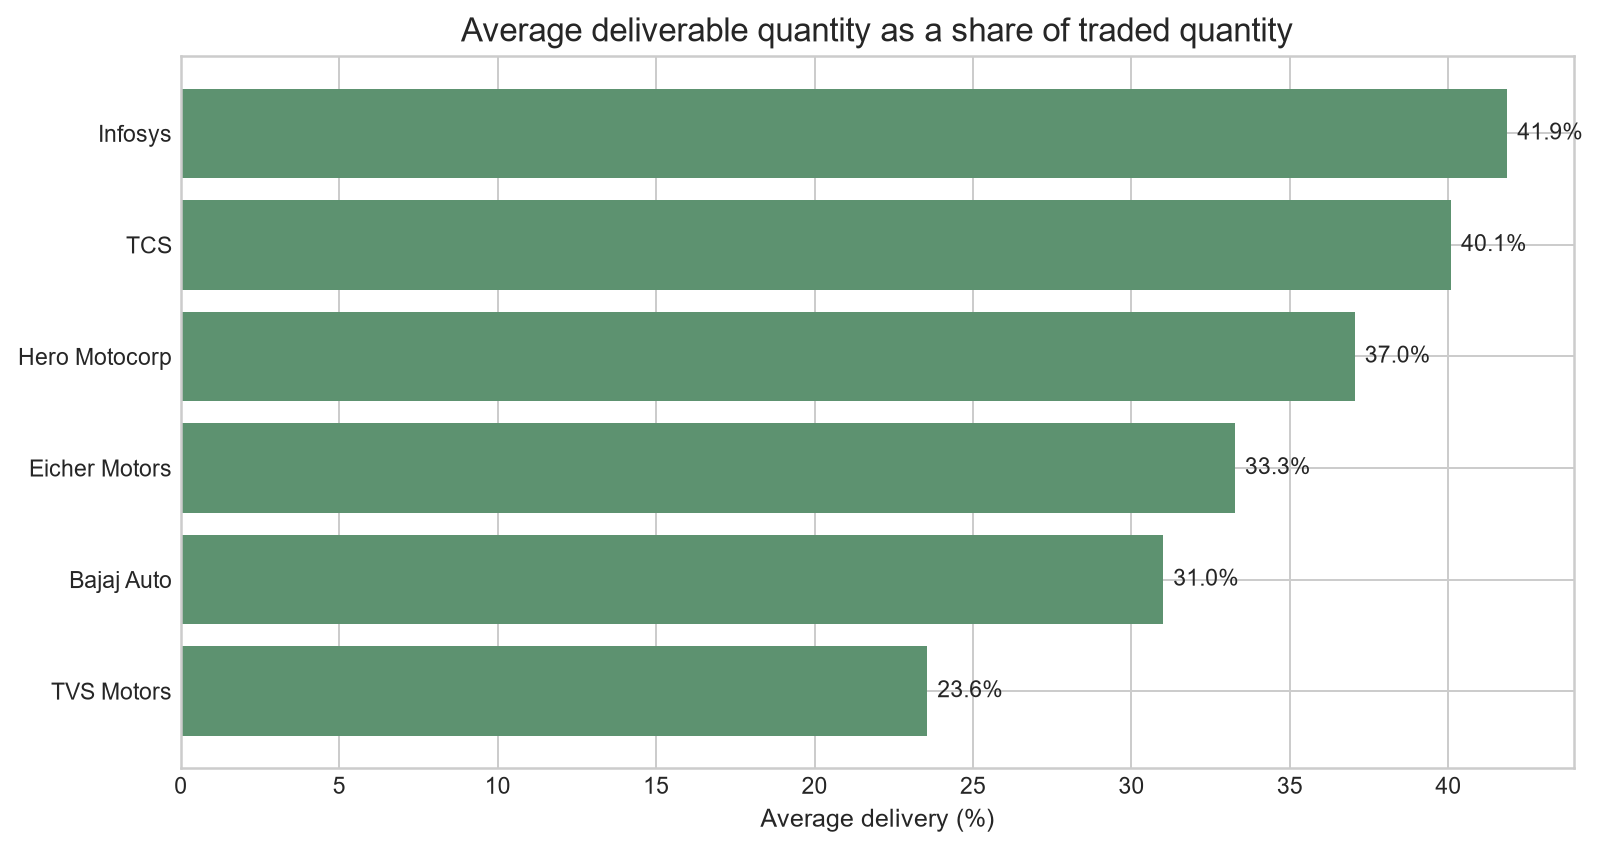

In [1]:
chart = metrics.sort_values("Avg delivery (%)")
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(chart.Company, chart["Avg delivery (%)"], color="#5d9270")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set(title="Average deliverable quantity as a share of traded quantity", xlabel="Average delivery (%)")
fig.tight_layout()
fig.savefig(CHARTS / "average_delivery.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


# Additional EDA using UBM chart types

These plots extend the company comparisons with **Univariate**, **Bivariate**, and **Multivariate** views.


## 10. Univariate: daily return distribution

A box plot summarizes daily return centers and spreads by company. Outlier markers are hidden for readability; quartiles are calculated from the original, unclipped returns.

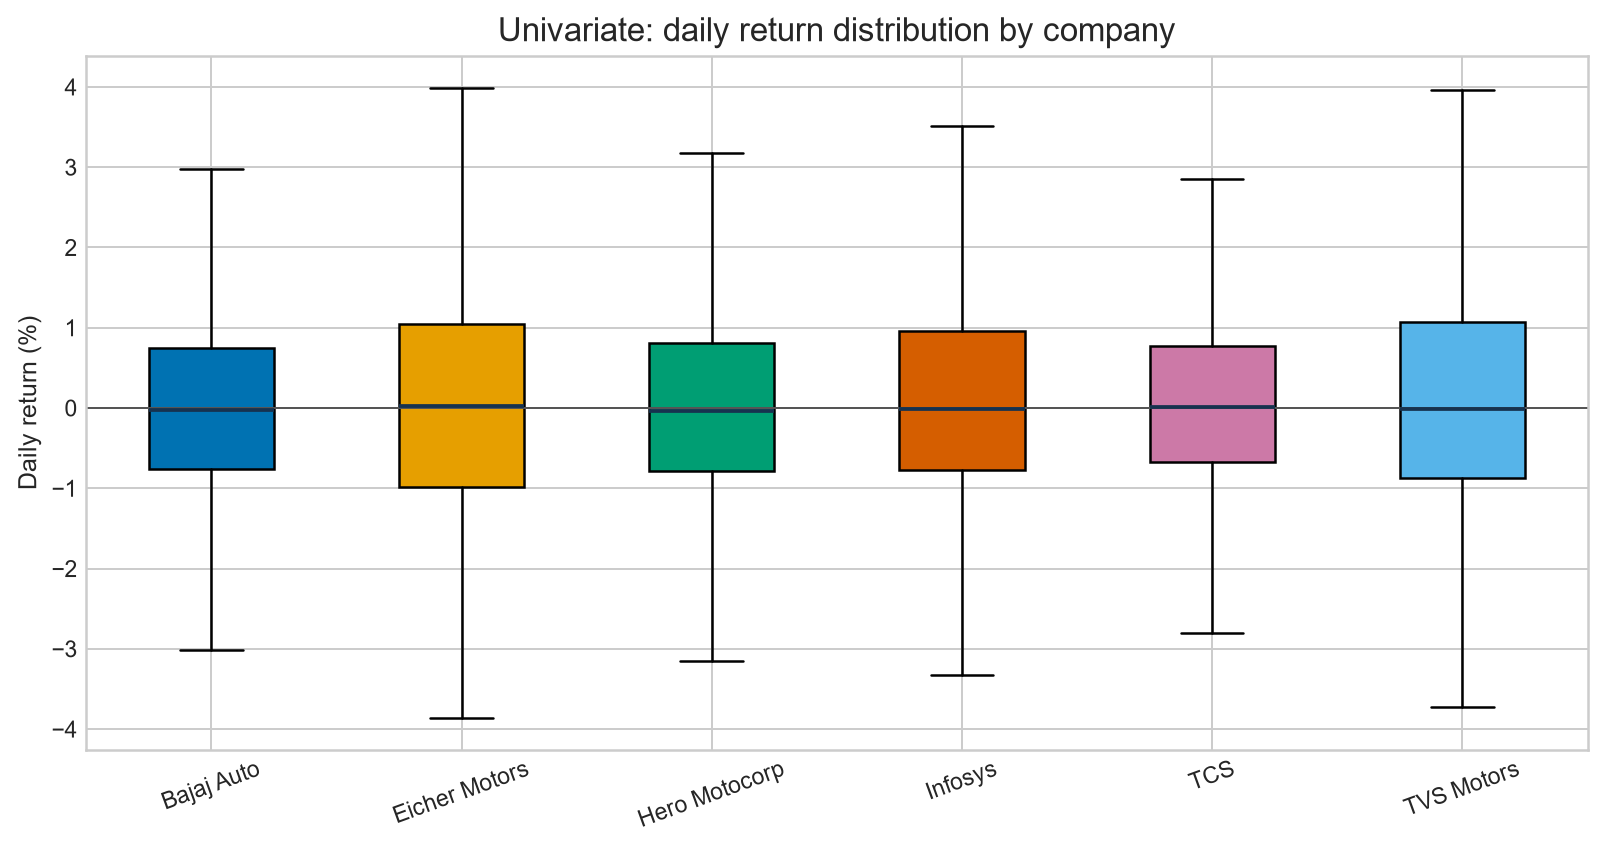

In [1]:
return_groups = [
    group["daily_return_pct"].dropna().to_numpy()
    for _, group in df.groupby("company")
]
return_labels = sorted(df.company.dropna().unique())
fig, ax = plt.subplots(figsize=(9, 4.8))
box = ax.boxplot(return_groups, tick_labels=return_labels, showfliers=False, patch_artist=True,
                 medianprops={"color": "#16324f", "linewidth": 1.5})
for patch, company in zip(box["boxes"], return_labels):
    patch.set_facecolor(company_colors.get(company, "#9fc4dc"))
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(title="Univariate: daily return distribution by company", ylabel="Daily return (%)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(CHARTS / "daily_return_distribution.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 11. Bivariate: shares traded and turnover

Hexagonal bins show how many days fall in each activity range. Both axes use a log scale so low and high activity days remain visible.

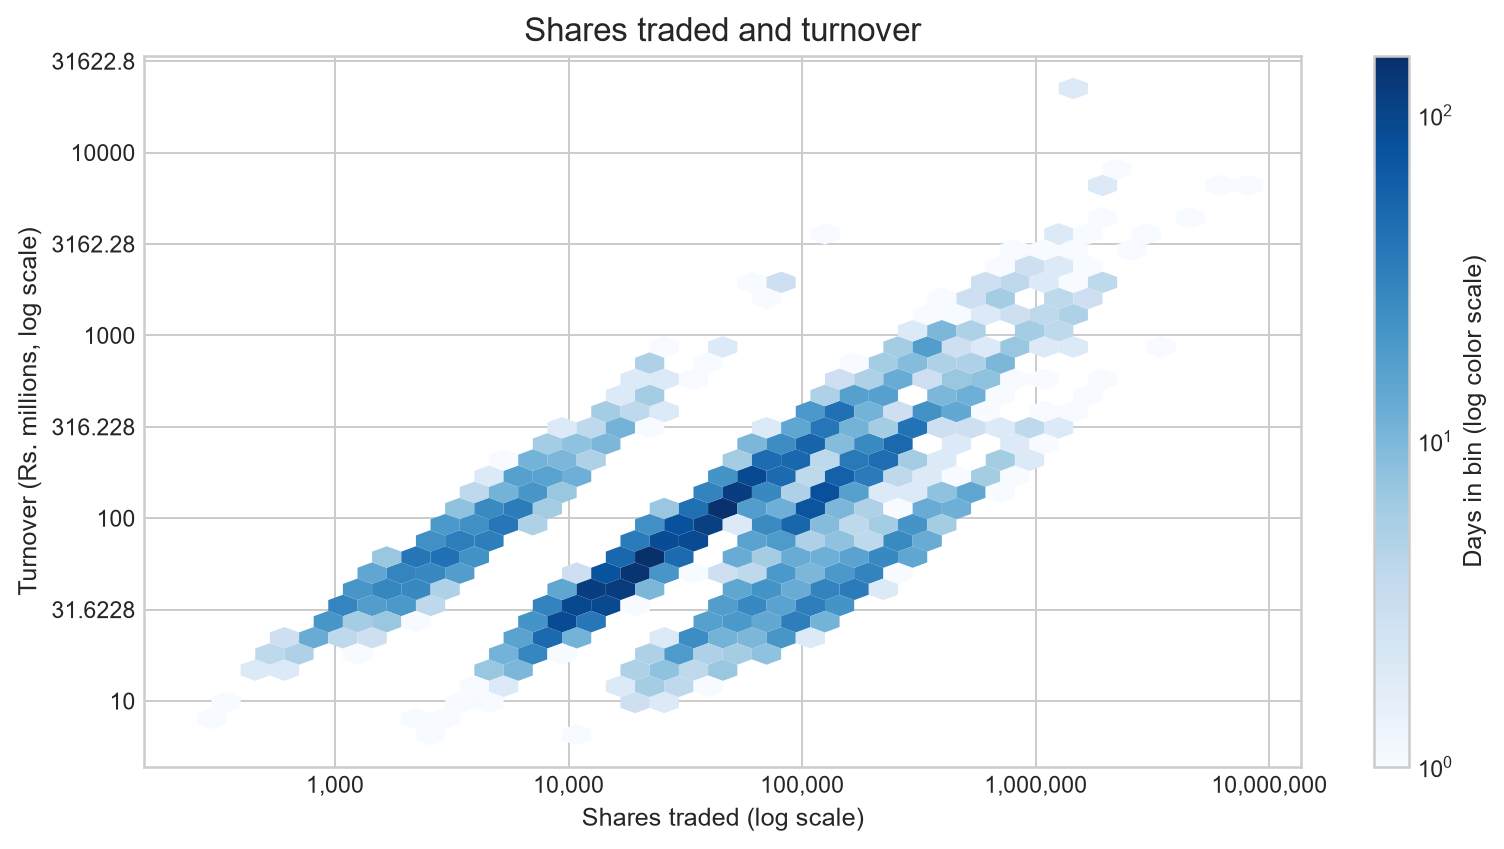

In [1]:
activity = df.dropna(subset=["shares_traded", "turnover"])
activity = activity[(activity.shares_traded > 0) & (activity.turnover > 0)]
fig, ax = plt.subplots(figsize=(9, 4.8))
x_log = np.log10(activity.shares_traded)
y_log = np.log10(activity.turnover / 1_000_000)
density = ax.hexbin(x_log, y_log, gridsize=36, mincnt=1, bins="log", cmap="Blues", linewidths=0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{10**value:,.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{10**value:g}"))
ax.set(title="Shares traded and turnover", xlabel="Shares traded (log scale)", ylabel="Turnover (Rs. millions, log scale)")
fig.colorbar(density, ax=ax, label="Days in bin (log color scale)")
fig.tight_layout()
fig.savefig(CHARTS / "shares_vs_turnover.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 12. Bivariate: delivery ratio and daily return

This scatter plot checks whether daily price movements co-vary with the deliverable share ratio.

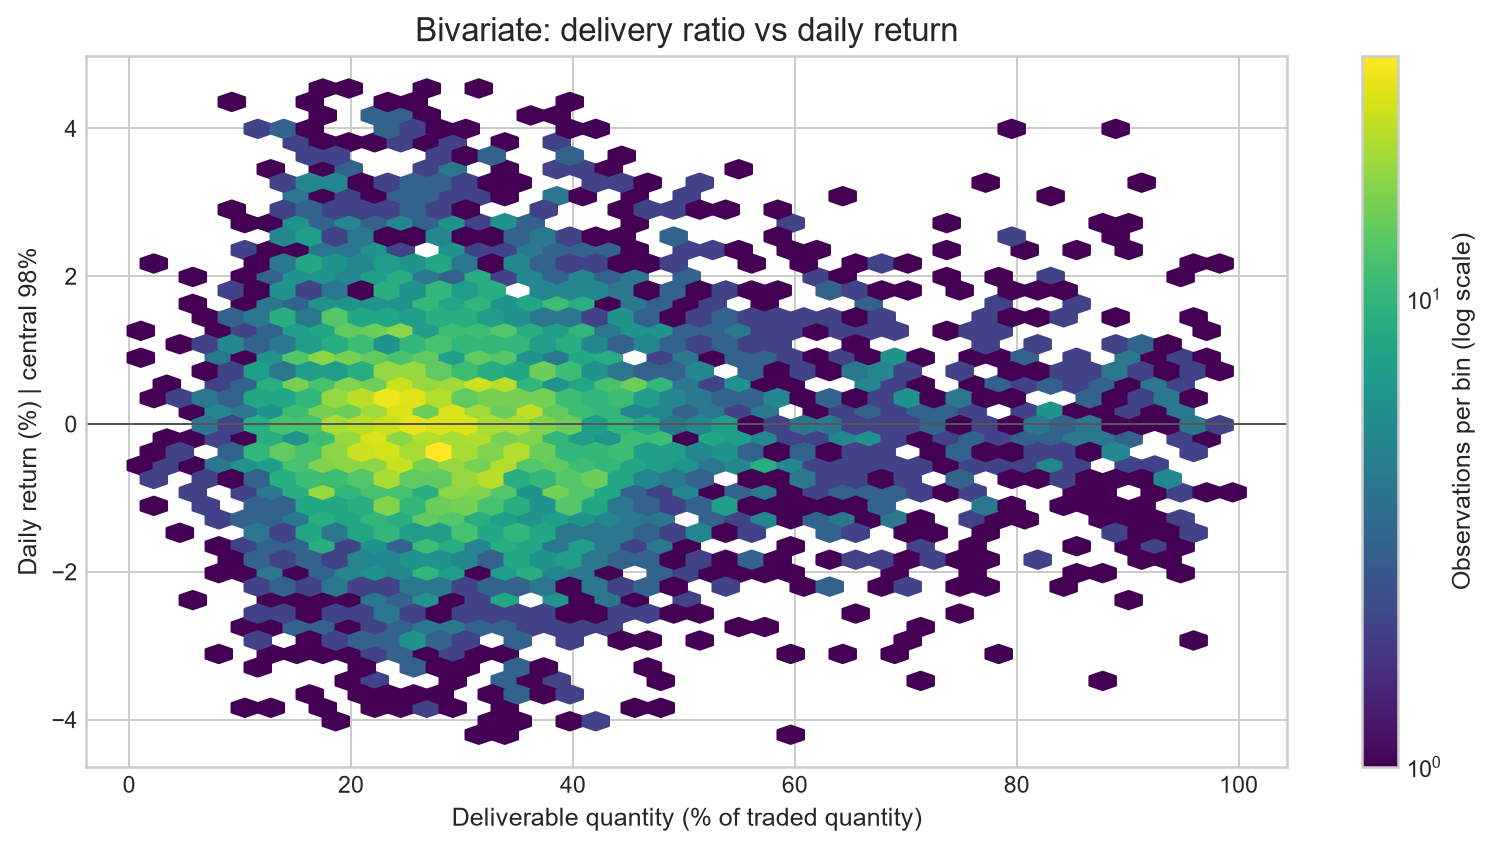

In [1]:
relation = df.dropna(subset=["deliverable_pct", "daily_return_pct"])
lower, upper = relation.daily_return_pct.quantile([0.01, 0.99])
relation = relation[relation.daily_return_pct.between(lower, upper)]
fig, ax = plt.subplots(figsize=(9, 4.8))
density = ax.hexbin(relation.deliverable_pct, relation.daily_return_pct, gridsize=42,
                    mincnt=1, bins="log", cmap="viridis")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(title="Bivariate: delivery ratio vs daily return", xlabel="Deliverable quantity (% of traded quantity)", ylabel="Daily return (%) | central 98%")
fig.colorbar(density, ax=ax, label="Observations per bin (log scale)")
fig.tight_layout()
fig.savefig(CHARTS / "delivery_vs_daily_return.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 13. Multivariate: Spearman correlation

The heatmap summarizes pairwise rank correlations among daily returns, share volume, turnover, and delivery ratio. Correlation describes association, not causation.

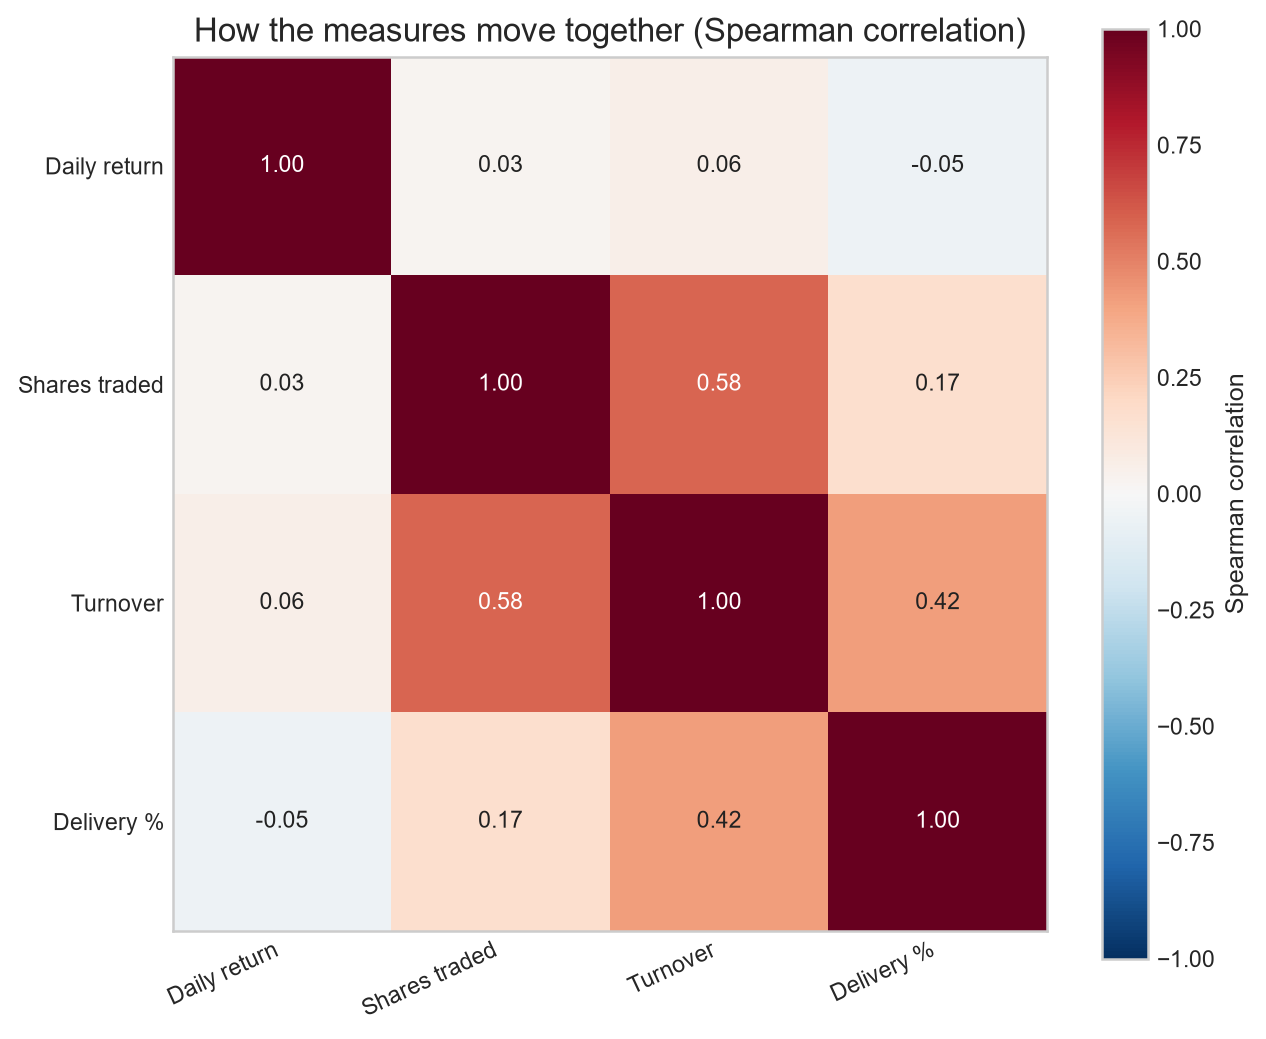

In [1]:
corr_columns = ["daily_return_pct", "shares_traded", "turnover", "deliverable_pct"]
corr = df[corr_columns].corr(method="spearman")
labels = ["Daily return", "Shares traded", "Turnover", "Delivery %"]
fig, ax = plt.subplots(figsize=(7.2, 6))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("#f4f6f8")
image = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.grid(False)
ax.set_xticks(range(len(labels)), labels, rotation=25, ha="right")
ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for col in range(len(labels)):
        value = corr.iloc[row, col]
        ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                fontsize=9, color="white" if abs(value) > 0.55 else "#222222")
ax.set_title("How the measures move together (Spearman correlation)")
fig.colorbar(image, ax=ax, label="Spearman correlation")
fig.tight_layout()
fig.savefig(CHARTS / "spearman_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 14. Multivariate: activity and returns

This bubble chart combines four variables: turnover on the x-axis, daily return on the y-axis, share volume as marker size, and delivery ratio as color.

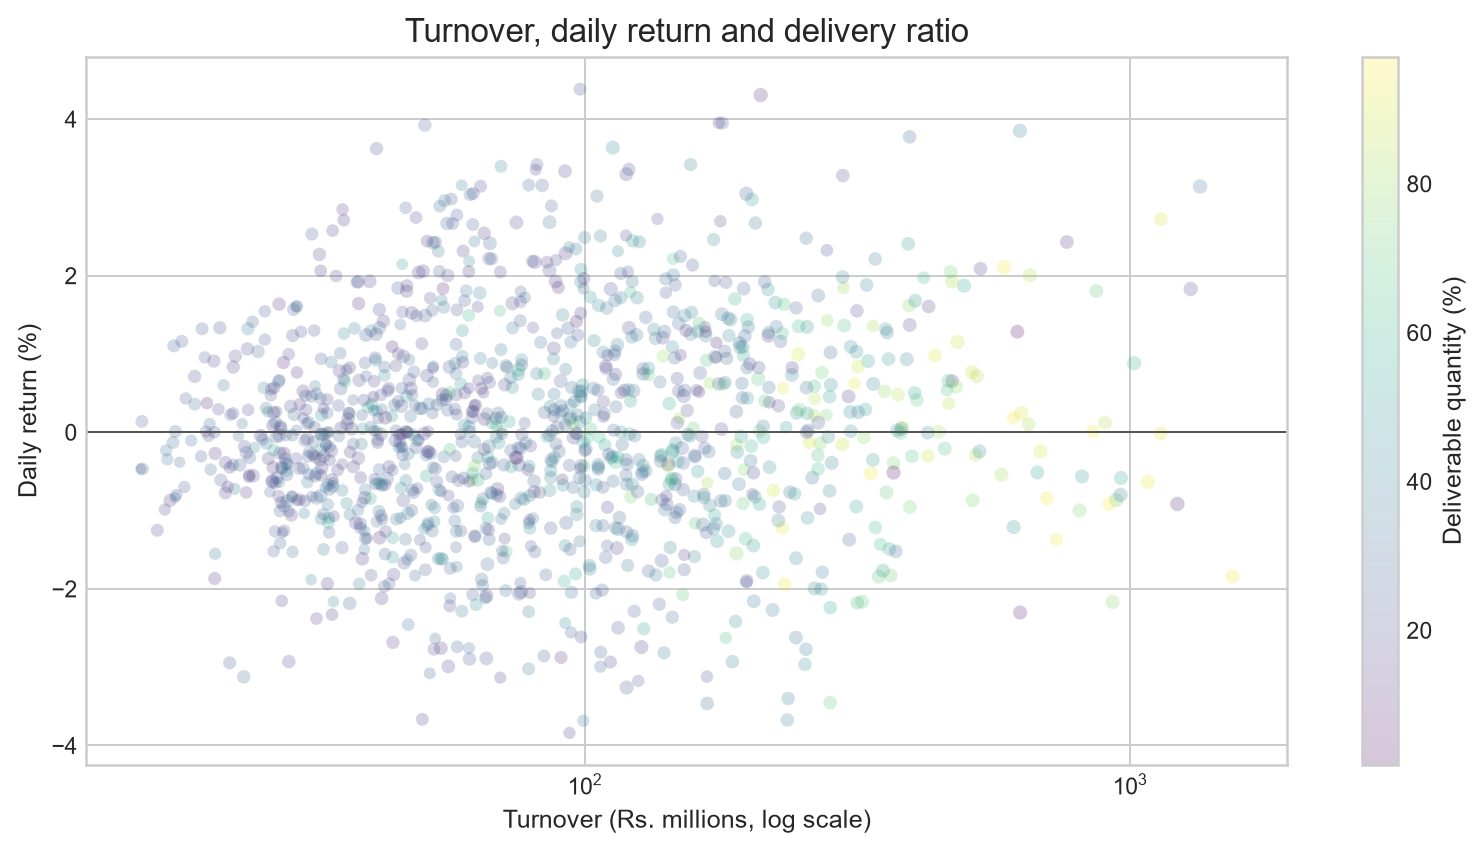

In [1]:
bubble = df.dropna(subset=["daily_return_pct", "turnover", "shares_traded", "deliverable_pct"])
x_low, x_high = bubble.turnover.quantile([0.01, 0.99])
y_low, y_high = bubble.daily_return_pct.quantile([0.01, 0.99])
bubble = bubble[bubble.turnover.between(x_low, x_high) & bubble.daily_return_pct.between(y_low, y_high)]
bubble = bubble.sample(n=min(1200, len(bubble)), random_state=42)
log_size = np.log1p(bubble.shares_traded.clip(lower=0))
size = 9 + 25 * (log_size / log_size.max()) if log_size.max() else 9
fig, ax = plt.subplots(figsize=(9, 4.8))
points = ax.scatter(bubble.turnover / 1_000_000, bubble.daily_return_pct,
                    s=size, c=bubble.deliverable_pct, cmap="viridis", alpha=0.22, edgecolors="none", rasterized=True)
ax.set_xscale("log")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(title="Turnover, daily return and delivery ratio", xlabel="Turnover (Rs. millions, log scale)", ylabel="Daily return (%)")
fig.colorbar(points, ax=ax, label="Deliverable quantity (%)")
fig.tight_layout()
fig.savefig(CHARTS / "multivariate_activity_returns.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)


## 15. Export charts and findings to PDF

This final cell exports the core charts and the UBM EDA charts to the project PDF.

In [1]:
chart_paths = [
    CHARTS / "indexed_closing_prices.png",
    CHARTS / "period_returns.png",
    CHARTS / "average_turnover.png",
    CHARTS / "average_delivery.png",
    CHARTS / "daily_return_distribution.png",
    CHARTS / "shares_vs_turnover.png",
    CHARTS / "delivery_vs_daily_return.png",
    CHARTS / "spearman_correlation_matrix.png",
    CHARTS / "multivariate_activity_returns.png",
]
make_pdf(df, metrics, chart_paths)
print(f"PDF written to: {PDF_PATH}")


PDF written to: D:\SQL - Stock Market Analysis Project\reports\Stock_Market_Analysis_Insights.pdf


## Reading the results

Period returns use each company's available history in the dataset, so the measurement windows can differ. These charts summarize historical observations and are not risk-adjusted or forward-looking.
